### Gamma=1

Extracting from Iteration3: 100%|██████████████████████████████████████████████████████| 54/54 [00:30<00:00,  1.76it/s]


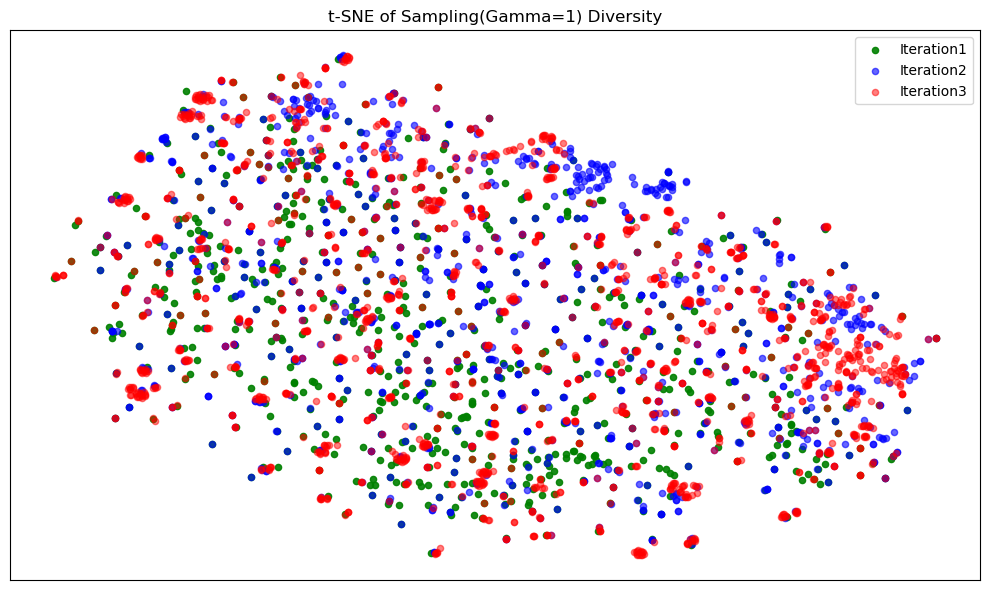

In [3]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.models import vgg16, VGG16_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


# ----------------------------
# ✅ 不需要分類子資料夾的 Dataset
# ----------------------------
class PlainImageFolder(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [os.path.join(folder_path, f)
                            for f in os.listdir(folder_path)
                            if f.lower().endswith((".png", ".jpg", ".jpeg"))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label

# ----------------------------
# ✅ 從資料夾提取 VGG 特徵
# ----------------------------
def extract_features_from_folder(folder_path, label_name, batch_size=32, device="cuda"):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    dataset = PlainImageFolder(folder_path, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    weights = VGG16_Weights.DEFAULT  # 或 IMAGENET1K_V1
    model = vgg16(weights=weights).features[:16].eval().to(device)
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc=f"Extracting from {label_name}"):
            imgs = imgs.to(device)
            feats = model(imgs)
            feats = torch.nn.functional.adaptive_avg_pool2d(feats, (1, 1)).squeeze()
            all_features.append(feats.cpu())
            all_labels += [label_name] * imgs.size(0)

    return torch.cat(all_features, dim=0).numpy(), np.array(all_labels)

# ----------------------------
# ✅ t-SNE 視覺化函式
# ----------------------------
def visualize_tsne_from_multiple_folders(folder_label_pairs, title="t-SNE: Diversity Comparison", device="cuda"):
    all_features = []
    all_labels = []

    for folder_path, label_name in folder_label_pairs:
        feats, labels = extract_features_from_folder(folder_path, label_name, device=device)
        all_features.append(feats)
        all_labels.append(labels)

    features = np.vstack(all_features)
    labels = np.concatenate(all_labels)

    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    embedded = tsne.fit_transform(features)

    # ✅ 手動指定顏色
    label_color_map = {
        "Iteration1": "green",
        "Iteration2": "blue",
        "Iteration3": "red"
    }

    # ✅ 給不同 iteration 設定透明度 (alpha) 與 zorder
    label_style_map = {
        "Iteration1": {"alpha": 0.9, "zorder": 1},  # 比較明顯
        "Iteration2": {"alpha": 0.6, "zorder": 2},  # 半透明
        "Iteration3": {"alpha": 0.5, "zorder": 3},  # 更透明
    }

    plt.figure(figsize=(10, 6))

    for label in label_color_map:
        idx = labels == label
        if np.sum(idx) == 0:
            continue
        plt.scatter(
            embedded[idx, 0], embedded[idx, 1],
            s=20,
            c=label_color_map[label],
            alpha=label_style_map[label]["alpha"],   # ✅ 透明度
            zorder=label_style_map[label]["zorder"], # ✅ 疊放層級
            label=label
        )

    plt.legend()
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()



# ----------------------------
# ✅ 主程式：指定資料夾與標籤
# ----------------------------
if __name__ == "__main__":
    folder_label_pairs = [
        ("C:/Users/ss890/Desktop/LPIPS/Itr1/Balanced Sampling", "Iteration1"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr2/Balanced Sampling", "Iteration2"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr3/Balanced Sampling", "Iteration3")
    ]

    visualize_tsne_from_multiple_folders(
        folder_label_pairs,
        title="t-SNE of Sampling(Gamma=1) Diversity",
        device="cuda" if torch.cuda.is_available() else "cpu"
        #device="cuda"
    )


In [2]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA 可用？", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA 版號(編譯目標):", torch.version.cuda)


PyTorch: 2.8.0+cpu
CUDA 可用？ False


In [5]:
import sys
print(sys.executable)
C:\Users\ss890\anaconda3\python.exe

C:\Users\ss890\anaconda3\python.exe


Extracting from Iteration3: 100%|██████████████████████████████████████████████████████| 43/43 [00:24<00:00,  1.77it/s]


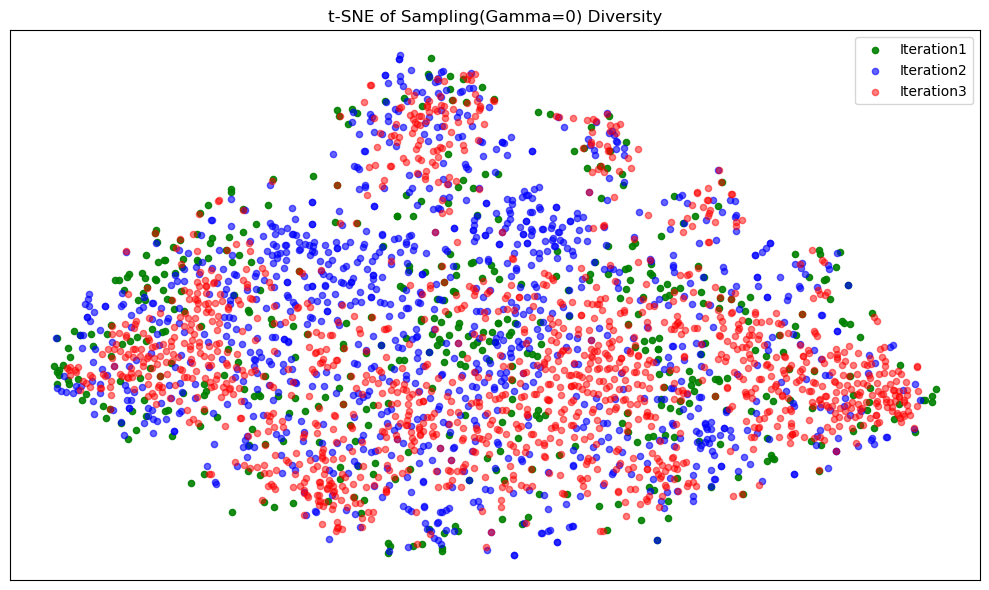

In [4]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.models import vgg16, VGG16_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


# ----------------------------
# ✅ 不需要分類子資料夾的 Dataset
# ----------------------------
class PlainImageFolder(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [os.path.join(folder_path, f)
                            for f in os.listdir(folder_path)
                            if f.lower().endswith((".png", ".jpg", ".jpeg"))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label

# ----------------------------
# ✅ 從資料夾提取 VGG 特徵
# ----------------------------
def extract_features_from_folder(folder_path, label_name, batch_size=32, device="cuda"):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    dataset = PlainImageFolder(folder_path, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    weights = VGG16_Weights.DEFAULT  # 或 IMAGENET1K_V1
    model = vgg16(weights=weights).features[:16].eval().to(device)
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc=f"Extracting from {label_name}"):
            imgs = imgs.to(device)
            feats = model(imgs)
            feats = torch.nn.functional.adaptive_avg_pool2d(feats, (1, 1)).squeeze()
            all_features.append(feats.cpu())
            all_labels += [label_name] * imgs.size(0)

    return torch.cat(all_features, dim=0).numpy(), np.array(all_labels)

# ----------------------------
# ✅ t-SNE 視覺化函式
# ----------------------------
def visualize_tsne_from_multiple_folders(folder_label_pairs, title="t-SNE: Diversity Comparison", device="cuda"):
    all_features = []
    all_labels = []

    for folder_path, label_name in folder_label_pairs:
        feats, labels = extract_features_from_folder(folder_path, label_name, device=device)
        all_features.append(feats)
        all_labels.append(labels)

    features = np.vstack(all_features)
    labels = np.concatenate(all_labels)

    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    embedded = tsne.fit_transform(features)

    # ✅ 手動指定顏色
    label_color_map = {
        "Iteration1": "green",
        "Iteration2": "blue",
        "Iteration3": "red"
    }

    # ✅ 給不同 iteration 設定透明度 (alpha) 與 zorder
    label_style_map = {
        "Iteration1": {"alpha": 0.9, "zorder": 1},  # 比較明顯
        "Iteration2": {"alpha": 0.6, "zorder": 2},  # 半透明
        "Iteration3": {"alpha": 0.5, "zorder": 3},  # 更透明
    }

    plt.figure(figsize=(10, 6))

    for label in label_color_map:
        idx = labels == label
        if np.sum(idx) == 0:
            continue
        plt.scatter(
            embedded[idx, 0], embedded[idx, 1],
            s=20,
            c=label_color_map[label],
            alpha=label_style_map[label]["alpha"],   # ✅ 透明度
            zorder=label_style_map[label]["zorder"], # ✅ 疊放層級
            label=label
        )

    plt.legend()
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()



# ----------------------------
# ✅ 主程式：指定資料夾與標籤
# ----------------------------
if __name__ == "__main__":
    folder_label_pairs = [
        ("C:/Users/ss890/Desktop/LPIPS/Itr1/Random Sampling", "Iteration1"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr2/Random Sampling", "Iteration2"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr3/Random Sampling", "Iteration3")
    ]

    visualize_tsne_from_multiple_folders(
        folder_label_pairs,
        title="t-SNE of Sampling(Gamma=0) Diversity",
        device="cuda" if torch.cuda.is_available() else "cpu"
        #device="cuda"
    )


Extracting from Gamma=1: 100%|█████████████████████████████████████████████████████████| 54/54 [00:29<00:00,  1.82it/s]


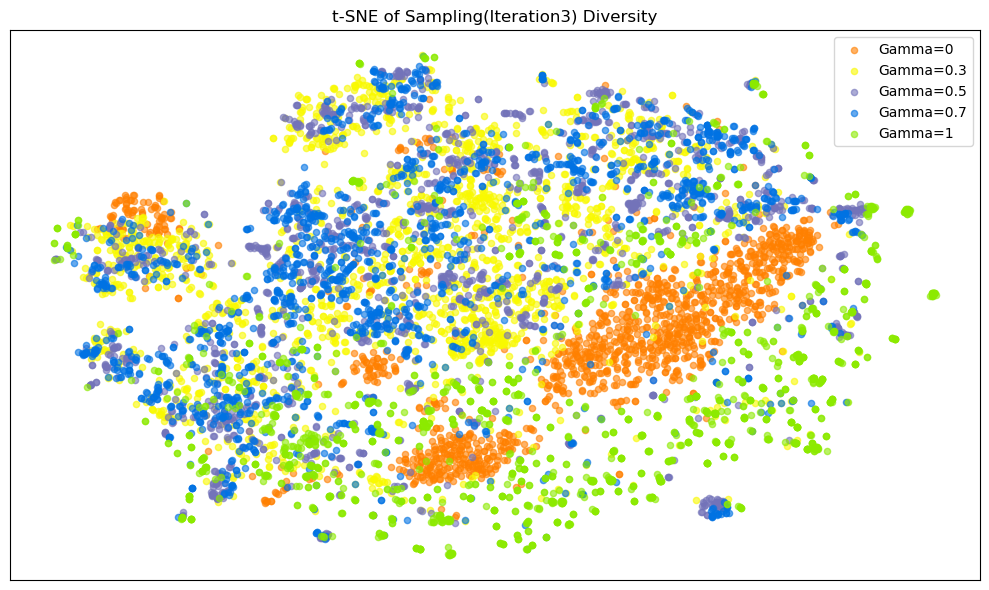

In [2]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.models import vgg16, VGG16_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


# ----------------------------
# ✅ 不需要分類子資料夾的 Dataset
# ----------------------------
class PlainImageFolder(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [os.path.join(folder_path, f)
                            for f in os.listdir(folder_path)
                            if f.lower().endswith((".png", ".jpg", ".jpeg"))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label

# ----------------------------
# ✅ 從資料夾提取 VGG 特徵
# ----------------------------
def extract_features_from_folder(folder_path, label_name, batch_size=32, device="cuda"):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    dataset = PlainImageFolder(folder_path, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    weights = VGG16_Weights.DEFAULT  # 或 IMAGENET1K_V1
    model = vgg16(weights=weights).features[:16].eval().to(device)
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc=f"Extracting from {label_name}"):
            imgs = imgs.to(device)
            feats = model(imgs)
            feats = torch.nn.functional.adaptive_avg_pool2d(feats, (1, 1)).squeeze()
            all_features.append(feats.cpu())
            all_labels += [label_name] * imgs.size(0)

    return torch.cat(all_features, dim=0).numpy(), np.array(all_labels)

# ----------------------------
# ✅ t-SNE 視覺化函式
# ----------------------------
def visualize_tsne_from_multiple_folders(folder_label_pairs, title="t-SNE: Diversity Comparison", device="cuda"):
    all_features = []
    all_labels = []

    for folder_path, label_name in folder_label_pairs:
        feats, labels = extract_features_from_folder(folder_path, label_name, device=device)
        all_features.append(feats)
        all_labels.append(labels)

    features = np.vstack(all_features)
    labels = np.concatenate(all_labels)

    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    embedded = tsne.fit_transform(features)

    # ✅ 手動指定顏色
    label_color_map = {
        "Gamma=0": "#FF8000",
        "Gamma=0.3": "#F9F900",
        "Gamma=0.5": "#7373B9",
        "Gamma=0.7": "#0072E3",
        "Gamma=1": "#8CEA00"
    }

    # ✅ 給不同 iteration 設定透明度 (alpha) 與 zorder
    label_style_map = {
        "Gamma=0": {"alpha": 0.6, "zorder": 1},  # 比較明顯
        "Gamma=0.3": {"alpha": 0.6, "zorder": 1},  # 半透明
        "Gamma=0.5": {"alpha": 0.6, "zorder": 1},  # 更透明
        "Gamma=0.7": {"alpha": 0.6, "zorder": 1},  # 比較明顯
        "Gamma=1": {"alpha": 0.6, "zorder": 1}  # 半透明
    }

    plt.figure(figsize=(10, 6))

    for label in label_color_map:
        idx = labels == label
        if np.sum(idx) == 0:
            continue
        plt.scatter(
            embedded[idx, 0], embedded[idx, 1],
            s=20,
            c=label_color_map[label],
            alpha=label_style_map[label]["alpha"],   # ✅ 透明度
            zorder=label_style_map[label]["zorder"], # ✅ 疊放層級
            label=label
        )

    plt.legend()
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()



# ----------------------------
# ✅ 主程式：指定資料夾與標籤
# ----------------------------
if __name__ == "__main__":
    folder_label_pairs = [
        ("C:/Users/ss890/Desktop/LPIPS/Itr3/Random Sampling", "Gamma=0"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr3/Gamma03", "Gamma=0.3"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr3/Gamma05", "Gamma=0.5"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr3/Gamma07", "Gamma=0.7"),
        ("C:/Users/ss890/Desktop/LPIPS/Itr3/Balanced Sampling", "Gamma=1")
    ]

    visualize_tsne_from_multiple_folders(
        folder_label_pairs,
        title="t-SNE of Sampling(Iteration3) Diversity",
        device="cuda" if torch.cuda.is_available() else "cpu"
        #device="cuda"
    )
